<a href="https://colab.research.google.com/github/jdansb/Econophysics/blob/main/files/fkkerplanck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

P inicial = 1.3656669579129148e-10

========== TESTE 1 ==========
Resíduo máximo = 0.003084306495342054
Resíduo médio  = 1.3438167479948002e-05

========== TESTE 2 ==========
Erro máximo A = 0.002406190124915941
Erro máximo B = 4.542429082963692e-05

========== TESTE 3 ==========
A médio = 0.9996122233846921
A mínimo = 0.9977994902589599
A máximo = 1.0

B médio = 1.3615078697893104e-05
B máximo = 8.335080497379325e-05

========== TESTE 4 ==========
Erro aproximação Eq.22 = 9.806582728119628e-05


/tmp/ipykernel_404/2927945341.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_int[i] = np.trapz(P[i:],w[i:])


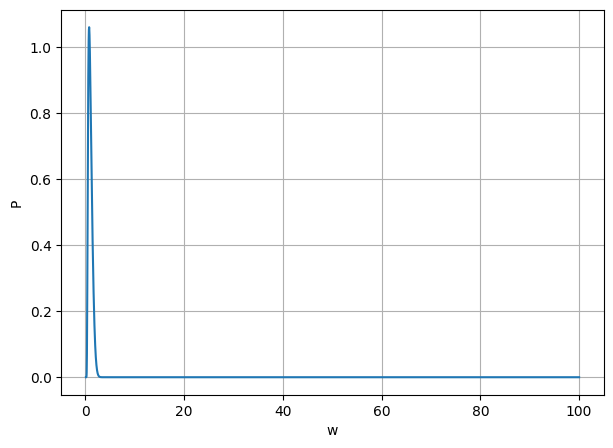

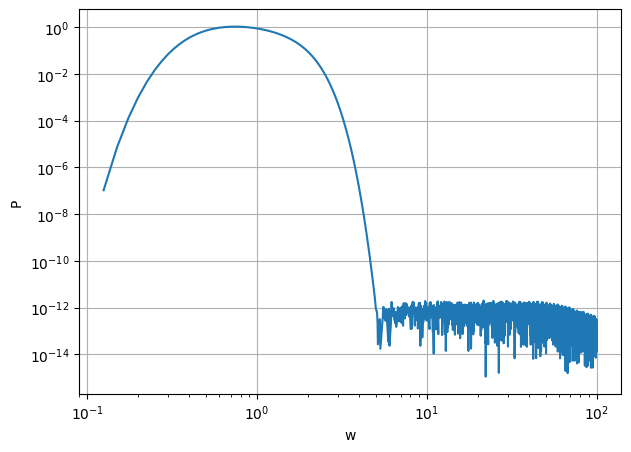

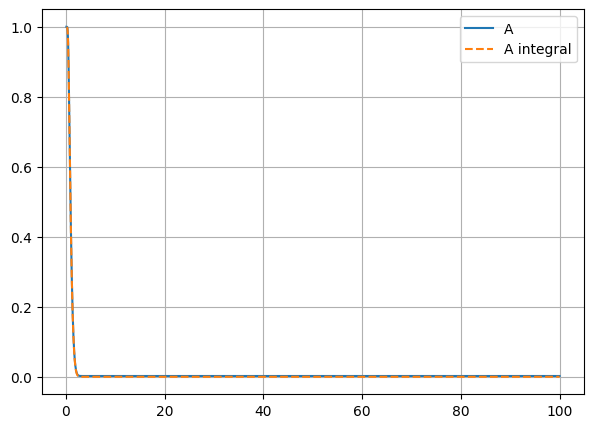

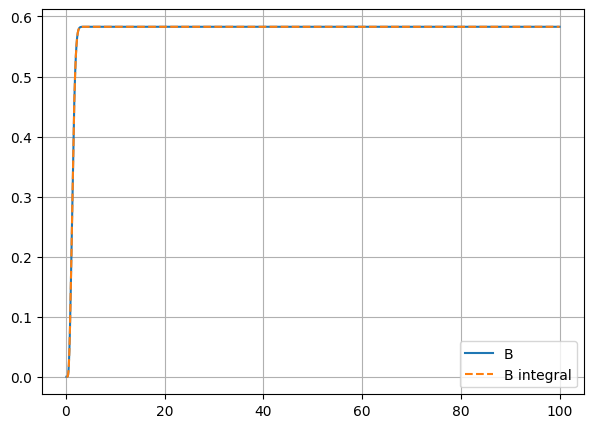

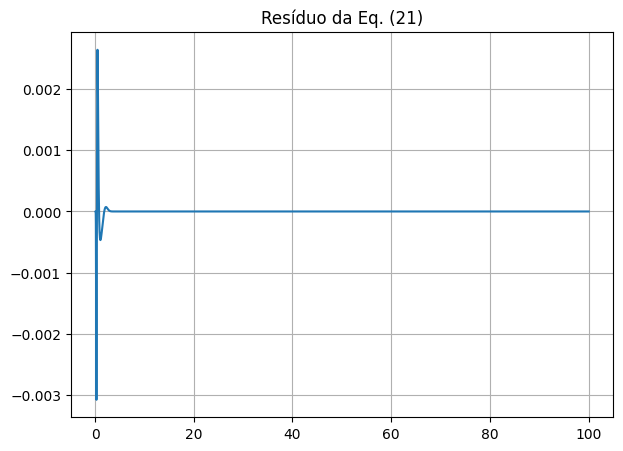

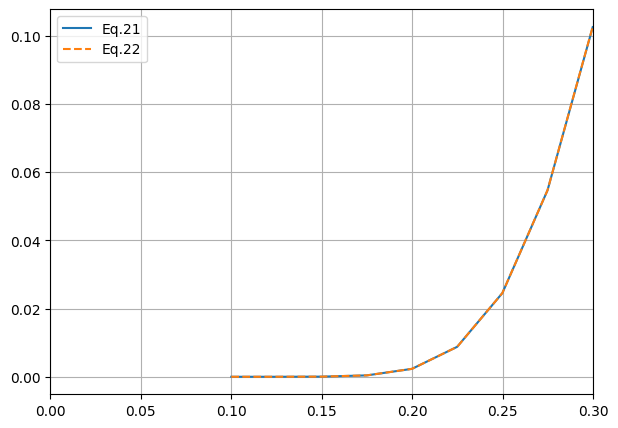

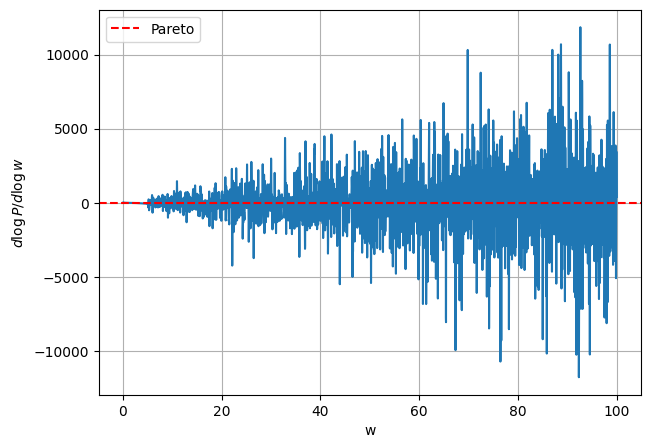

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.optimize import root_scalar

# =====================================================
# PARÂMETROS
# =====================================================

chi = 2

w_start = 0.1
w_end   = 100

# =====================================================
# SISTEMA DE EDOS
# =====================================================

def ode(w,y):

    P,A,B = y

    denom = 0.5*w*w*A + B

    if denom < 1e-15:
        denom = 1e-15

    dP = ((chi*(1-w)-w*A)/denom)*P
    dA = -P
    dB = 0.5*w*w*P

    return [dP,dA,dB]

# =====================================================
# MÉTODO DO TIRO
# =====================================================

def shoot(P0):

    sol = solve_ivp(
        ode,
        [w_start,w_end],
        [P0,1,0],
        rtol=1e-10,
        atol=1e-12
    )

    return sol.y[1,-1]

res = root_scalar(
    shoot,
    bracket=[1e-10,2],
    method='brentq'
)

P0 = res.root

print("P inicial =",P0)

# =====================================================
# SOLUÇÃO FINAL
# =====================================================

sol = solve_ivp(
    ode,
    [w_start,w_end],
    [P0,1,0],
    t_eval=np.linspace(w_start,w_end,4000),
    rtol=1e-10,
    atol=1e-12
)

w = sol.t
P = sol.y[0]
A = sol.y[1]
B = sol.y[2]

# =====================================================
# TESTE 1
# RESÍDUO DA EDO
# =====================================================

Q = (0.5*w**2*A+B)*P

dQ = np.gradient(Q,w)

R = chi*(1-w)*P-dQ

print()
print("========== TESTE 1 ==========")
print("Resíduo máximo =",np.max(np.abs(R)))
print("Resíduo médio  =",np.mean(np.abs(R)))

# =====================================================
# TESTE 2
# RECONSTRUÇÃO DE A
# =====================================================

A_int = np.zeros_like(w)

for i in range(len(w)-1):

    A_int[i] = np.trapz(P[i:],w[i:])

# =====================================================
# TESTE 3
# RECONSTRUÇÃO DE B
# =====================================================

B_int = cumulative_trapezoid(
    0.5*w**2*P,
    w,
    initial=0
)

print()
print("========== TESTE 2 ==========")
print("Erro máximo A =",np.max(np.abs(A-A_int)))
print("Erro máximo B =",np.max(np.abs(B-B_int)))

# =====================================================
# TESTE 4
# HIPÓTESE DO ARTIGO
# A≈1
# B≈0
# =====================================================

# Este 'mask_short_range' é específico para a região de w < 0.3
mask_short_range = w<0.3

print()
print("========== TESTE 3 ==========")

print("A médio =",np.mean(A[mask_short_range]))
print("A mínimo =",np.min(A[mask_short_range]))
print("A máximo =",np.max(A[mask_short_range]))

print()

print("B médio =",np.mean(B[mask_short_range]))
print("B máximo =",np.max(B[mask_short_range]))

# =====================================================
# TESTE 5
# EQUAÇÃO 22
# =====================================================

Qapprox = 0.5*w**2*P

dQapprox = np.gradient(Qapprox,w)

erro22 = np.max(np.abs(dQ[mask_short_range]-dQapprox[mask_short_range]))

print()
print("========== TESTE 4 ==========")
print("Erro aproximação Eq.22 =",erro22)

# =====================================================
# TESTE 6
# EXPOENTE LOCAL
# =====================================================

# Define uma máscara consistente para todos os gráficos log-log e cálculo de alpha
mask_for_log_plots = (P > 1e-15) & (w > 0.1)

alpha = np.gradient(
    np.log(P[mask_for_log_plots]),
    np.log(w[mask_for_log_plots])
)

# =====================================================
# GRÁFICOS
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(w,P)
plt.xlabel("w")
plt.ylabel("P")
plt.grid()

plt.figure(figsize=(7,5))
plt.loglog(w[mask_for_log_plots],P[mask_for_log_plots]) # Usa a máscara consistente
plt.xlabel("w")
plt.ylabel("P")
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w,A,label="A")
plt.plot(w,A_int,"--",label="A integral")
plt.legend()
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w,B,label="B")
plt.plot(w,B_int,"--",label="B integral")
plt.legend()
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w,R)
plt.title("Resíduo da Eq. (21)")
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w[mask_short_range],dQ[mask_short_range],label="Eq.21")
plt.plot(w[mask_short_range],dQapprox[mask_short_range],'--',label="Eq.22")
plt.xlim(0,0.3)
plt.legend()
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w[mask_for_log_plots],alpha) # Usa a máscara consistente
plt.axhline(-3,color='r',ls='--',label='Pareto')
plt.xlabel("w")
plt.ylabel(r"$d\log P/d\log w$")
plt.legend()
plt.grid()


# =====================================================
# DIAGNÓSTICO FINAL - EXPOENTE LOCAL
# =====================================================


<>:34: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\i'
<>:34: SyntaxWarning: invalid escape sequence '\e'
<>:34: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_404/4065595979.py:34: SyntaxWarning: invalid escape sequence '\e'
  plt.loglog(w_teo_high, P_teo_high, 'g--', linewidth=2, label=f'Gaussiana: $\exp(-{chi:.1f} w^2 / (2 B_\infty))$')
/tmp/ipykernel_404/4065595979.py:34: SyntaxWarning: invalid escape sequence '\i'
  plt.loglog(w_teo_high, P_teo_high, 'g--', linewidth=2, label=f'Gaussiana: $\exp(-{chi:.1f} w^2 / (2 B_\infty))$')


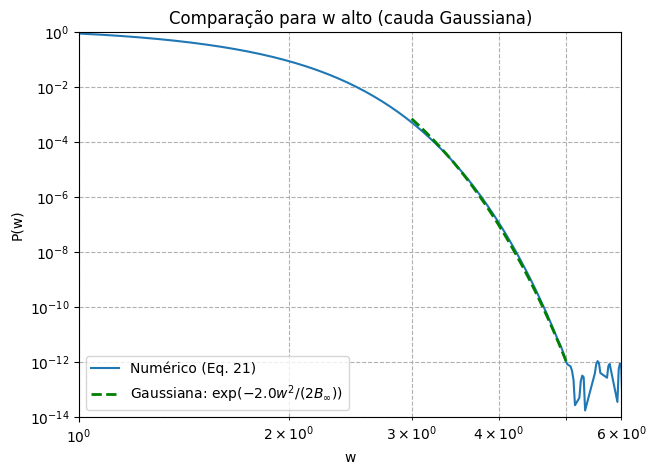

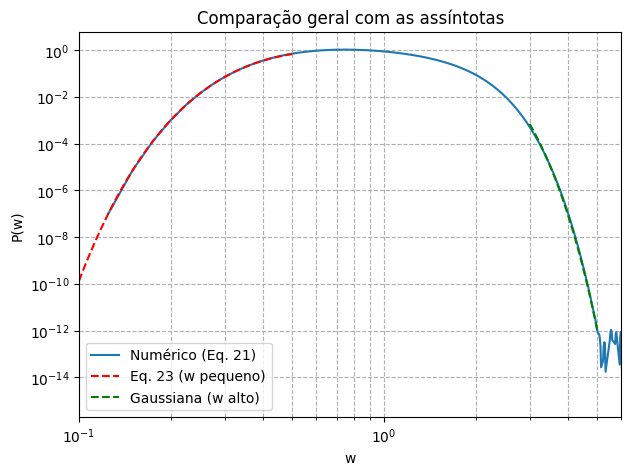

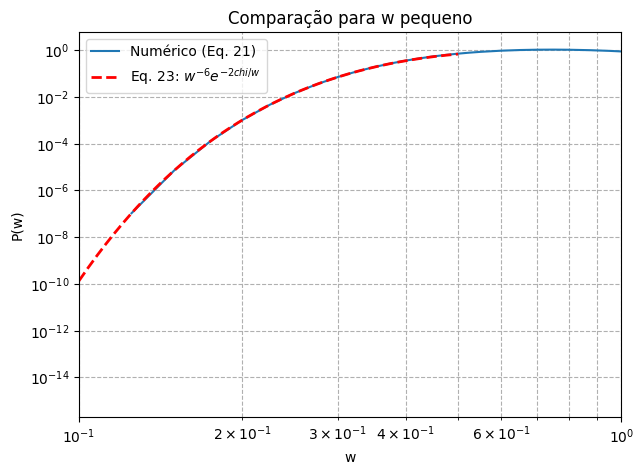

In [162]:
# =====================================================
# COMPARAÇÕES TEÓRICAS PARA w PEQUENO E w ALTO
# =====================================================

# --- 1. Ajuste da constante C para w pequeno (Eq. 23) ---
# Escolhe um ponto na região de w pequeno (ex: w ≈ 0.2)
w_ref_small = 0.2
idx_small = np.argmin(np.abs(w - w_ref_small))
C_small = P[idx_small] * (w_ref_small ** (2*(chi+1))) * np.exp(2*chi / w_ref_small)

# Gera a curva teórica para w pequeno
w_teo_small = np.linspace(w_start, 0.5, 200)  # até w=1 para ver a transição
P_teo_small = C_small * w_teo_small ** (-2*(chi+1)) * np.exp(-2*chi / w_teo_small)

# --- 2. Ajuste da constante C para w alto (Gaussiana) ---
# Estima B_infinito a partir do último valor de B
B_inf = B[-1]*1.35

# Escolhe um ponto na cauda (ex: w ≈ 10) para ajustar a constante
w_ref_high = 5.0
idx_high = np.argmin(np.abs(w - w_ref_high))
C_high = P[idx_high] / np.exp(-chi * w_ref_high**2 / (2 * B_inf))

# Gera a curva teórica para w alto
w_teo_high = np.linspace(3, 5, 300)
P_teo_high = C_high * np.exp(-chi * w_teo_high**2 / (2 * B_inf))

# --- 3. Gráficos de comparação ---


# (b) Comparação para w alto (log-log)
plt.figure(figsize=(7,5))
plt.loglog(w[mask_for_log_plots], P[mask_for_log_plots], label='Numérico (Eq. 21)')
plt.loglog(w_teo_high, P_teo_high, 'g--', linewidth=2, label=f'Gaussiana: $\exp(-{chi:.1f} w^2 / (2 B_\infty))$')
plt.xlim(1, 6)
plt.ylim(1E-14, 1)
plt.xlabel('w')
plt.ylabel('P(w)')
plt.title('Comparação para w alto (cauda Gaussiana)')
plt.legend()
plt.grid(True, which='both', linestyle='--')

# (c) Comparação dupla (apenas para visualização geral)
plt.figure(figsize=(7,5))
plt.loglog(w[mask_for_log_plots], P[mask_for_log_plots], label='Numérico (Eq. 21)')
plt.loglog(w_teo_small, P_teo_small, 'r--', label='Eq. 23 (w pequeno)')
plt.loglog(w_teo_high, P_teo_high, 'g--', label='Gaussiana (w alto)')
plt.xlim(0.1, 6)
plt.xlabel('w')
plt.ylabel('P(w)')
plt.title('Comparação geral com as assíntotas')
plt.legend()
plt.grid(True, which='both', linestyle='--')

plt.show()

# (a) Comparação para w pequeno (log-log)
plt.figure(figsize=(7,5))
plt.loglog(w[mask_for_log_plots], P[mask_for_log_plots], label='Numérico (Eq. 21)')
plt.loglog(w_teo_small, P_teo_small, 'r--', linewidth=2, label=f'Eq. 23: $w^{{-{2*(chi+1)}}} e^{{-2chi/w}}$')
plt.xlim(w_start, 1.0)
plt.xlabel('w')
plt.ylabel('P(w)')
plt.title('Comparação para w pequeno')
plt.legend()
plt.grid(True, which='both', linestyle='--')
